# Generated relighting — decomposition & relight overview

Decompositions of the **generated** relighting datasets (`canonical/<DOMAIN>_GENERATED/<gen_cfg>/<scene>`,
built by `scripts/build_generated_dataset.py`) under the study's `CONFIG`, comparing:

- **domain** `INFINITE` (true GT) vs `MIT` (Marigold GT),
- **generation config** `gen_cfg` — the `--postfix` given to `scripts/comfy_relight_batch.py`
  (e.g. `cfg1`, `cfg5`, `neg_shadow`); domains and gen_cfgs are discovered dynamically from the
  results tree, so any postfix appears here automatically, and
- **`with_source`** (the linear source added as an extra observation) vs **`no_source`** (relits only).

There is **no GT lighting** for the artistic named lightings, so relighting is judged against the
**GT intrinsics** via a synthetic azimuth sweep (GT-intrinsics render vs EST-intrinsics render).
The generated relit frames are shown as a **reference strip**.

Run the study first: `python scripts/generated_decomp_study.py`.

In [2]:
import sys, os, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# repo root
p = Path.cwd()
while not (p / "idr").is_dir() and p != p.parent:
    p = p.parent
os.chdir(p); sys.path[:0] = [str(p), str(p / "scripts")]
print("repo:", p)

from idr.data.scene_io import load_scene
from canonical_relight_render import (render_comparison, render_relight_video,
    load_est_intrinsics, load_gt_intrinsics, reference_relight_rmse)

from generated_decomp_study import DEFAULT_CONFIG

CANON  = p / "local_datasets" / "canonical"
CONFIG = DEFAULT_CONFIG    # auto-follows the study script; override with a string to view another run
STUDY  = p / "results" / "generated_study" / CONFIG
DEVICE = "cuda"            # set "cpu" if the GPU is busy
def ds_dir(domain, gen_cfg, scene):        # per-domain dataset leaf
    return CANON / f"{domain}_GENERATED" / gen_cfg / scene
print("canonical:", CANON)
print("config   :", CONFIG)
print("study    :", STUDY, "| exists:", STUDY.exists())

SOURCES = ["no_source"]
# SOURCES = ["no_source", "with_source"]

repo: /home/felix/Projects/image-intrinsics
canonical: /home/felix/Projects/image-intrinsics/local_datasets/canonical
config   : metallic_l1_1e-2_tv1e-3_light_mono
study    : /home/felix/Projects/image-intrinsics/results/generated_study/metallic_l1_1e-2_tv1e-3_light_mono | exists: True


## 1. Study summary

In [3]:
rows = []
for rp in sorted(STUDY.glob("*/*/*/*/results.json")):   # <domain>/<gen_cfg>/<scene>/<source>
    domain, gen_cfg, scene, source = rp.parts[-5:-1]     # identity from PATH (version-independent)
    r = json.loads(rp.read_text()); m = r.get("metrics", {})
    ds = r.get("ds") or r.get("cfg", {}).get("downsample", 1)    # fall back for older results.json
    rows.append(dict(domain=domain, gen_cfg=gen_cfg, scene=scene, source=source,
                     ds=int(ds), n_images=r.get("n_images"),
                     albedo_rmse=m.get("albedo_rmse"), roughness_rmse=m.get("roughness_rmse"),
                     metallic_rmse=m.get("metallic_rmse"), recon_rmse=m.get("recon_rmse"),
                     out_dir=r.get("out_dir", str(rp.parent))))
df = pd.DataFrame(rows)
assert len(df), f"no results under {STUDY} — run scripts/generated_decomp_study.py first"
METRICS = ["albedo_rmse", "roughness_rmse", "metallic_rmse", "recon_rmse"]
display(df[["domain", "gen_cfg", "scene", "source", "ds", "n_images"] + METRICS].round(4))

,domain,gen_cfg,scene,source,ds,n_images,albedo_rmse,roughness_rmse,metallic_rmse,recon_rmse
0,INFINITE,cfg1,bathroom_8616_sh_opaque,no_source,1,16,0.2233,0.3672,0.3598,0.0158
1,INFINITE,cfg1,bathroom_8616_sh_opaque,with_source,1,17,0.2223,0.3685,0.3597,0.0176
2,INFINITE,cfg5,bathroom_8616_sh_opaque,no_source,1,16,0.3069,0.4399,0.3782,0.0822
3,INFINITE,cfg5,bathroom_8616_sh_opaque,with_source,1,17,0.2921,0.4368,0.3788,0.0835
4,INFINITE,cfg5,diningroom_830_sh_opaque,no_source,2,16,0.5365,0.3542,0.3343,0.1300
5,INFINITE,neg_shadow,bathroom_8616_sh_opaque,no_source,2,16,0.2818,0.5242,0.3846,0.0702
6,INFINITE,neg_shadow,diningroom_830_sh_opaque,no_source,2,16,0.5047,0.3784,0.1681,0.1077
7,INFINITE,neg_shadow_light,bathroom_8616_sh_opaque,no_source,2,16,0.2251,0.4600,0.3607,0.0451
8,INFINITE,neg_shadow_light,diningroom_830_sh_opaque,no_source,2,16,0.2912,0.3703,0.0907,0.0815
9,MIT,cfg1,everett_kitchen12,no_source,4,16,0.3093,0.3371,0.3413,0.0265


## 2. with_source vs no_source

Lower is better. One panel per metric; x = `domain/gen_cfg`, bars grouped by `source`.
For MIT the GT is Marigold (so RMSE is vs the Marigold maps, not true GT).

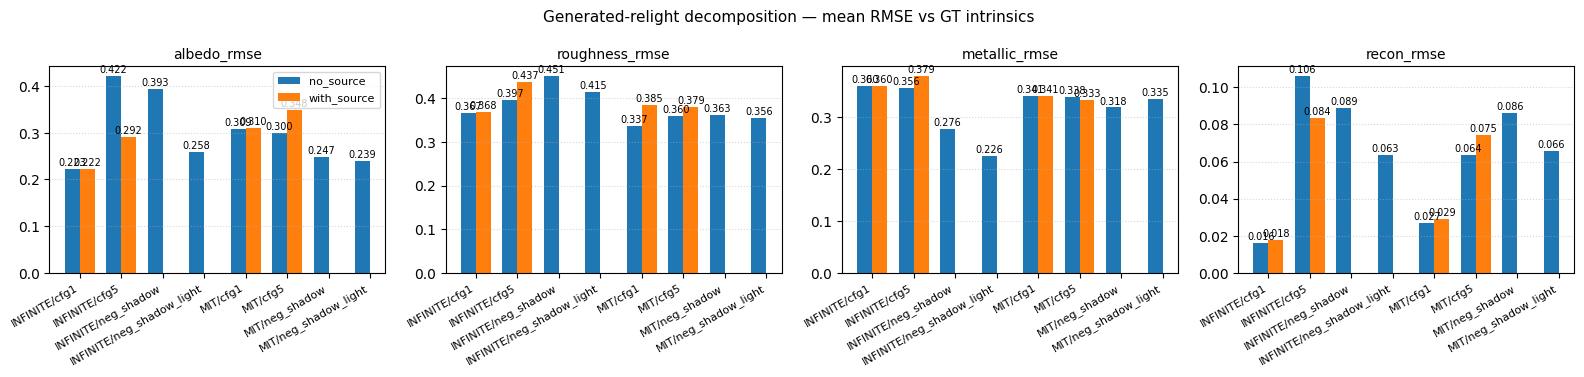

In [4]:
df["group"] = df["domain"] + "/" + df["gen_cfg"]
agg = df.groupby(["group", "source"])[METRICS].mean()
srcs = ["no_source", "with_source"]
groups = sorted(df["group"].unique())
fig, axes = plt.subplots(1, len(METRICS), figsize=(4 * len(METRICS), 3.8))
axes = np.atleast_1d(axes)
x = np.arange(len(groups)); w = 0.36
for ax, met in zip(axes, METRICS):
    for j, src in enumerate(srcs):
        vals = [agg.loc[(g, src), met] if (g, src) in agg.index else np.nan for g in groups]
        b = ax.bar(x + (j - 0.5) * w, vals, w, label=src)
        ax.bar_label(b, fmt="%.3f", fontsize=7, padding=1)
    ax.set_xticks(x); ax.set_xticklabels(groups, rotation=30, ha="right", fontsize=8)
    ax.set_title(met, fontsize=10); ax.grid(axis="y", ls=":", alpha=0.5)
axes[0].legend(fontsize=8)
fig.suptitle("Generated-relight decomposition — mean RMSE vs GT intrinsics", fontsize=11)
plt.tight_layout(); plt.show()

## 3. Pick a domain / scene / generation config

`SOURCE` selects which decomposition run to visualise (`with_source` / `no_source`).

In [16]:
DOMAIN  = sorted(df["domain"].unique())[0]         # "INFINITE" or "MIT"
sub     = df[df.domain == DOMAIN]
GEN_CFG = sorted(sub["gen_cfg"].unique())[1]       # "cfg1" / "cfg5" / neg_shadow / neg_shadow_light
SCENE   = sorted(sub[sub.gen_cfg == GEN_CFG]["scene"].unique())[1]
# SOURCE  = "with_source"
SOURCE  = "no_source"

DS_DIR  = ds_dir(DOMAIN, GEN_CFG, SCENE)
DS      = int(df[(df.domain == DOMAIN) & (df.gen_cfg == GEN_CFG) & (df.scene == SCENE)]["ds"].iloc[0])
def run_dir(source): return STUDY / DOMAIN / GEN_CFG / SCENE / source
RUN_DIR = run_dir(SOURCE)
print("dataset :", DS_DIR, "| downsample:", DS)
print("run     :", RUN_DIR, "| exists:", RUN_DIR.exists())
lights = json.loads((DS_DIR / "lights.json").read_text())
print(f"{len(lights)} generated lightings:", ", ".join(l["name"] for l in lights))

dataset : /home/felix/Projects/image-intrinsics/local_datasets/canonical/INFINITE_GENERATED/cfg5/diningroom_830_sh_opaque | downsample: 2
run     : /home/felix/Projects/image-intrinsics/results/generated_study/metallic_l1_1e-2_tv1e-3_light_mono/INFINITE/cfg5/diningroom_830_sh_opaque/no_source | exists: True
16 generated lightings: Bottom-up, Bright_ambient, Combined_NE+SW, Cool_low-angle, Flat_ambient, Front_(on-axis), Key_NE_high, Key_NW_high, Key_SE_low, Key_SW_low, Top-down, Warm_low-angle, cool_overcast, harsh_noon, warm_sun_left, warm_sun_right


## 4. Reference strip — the generated relit frames + source

These are the *observations* fed to the decomposition (source shown last).

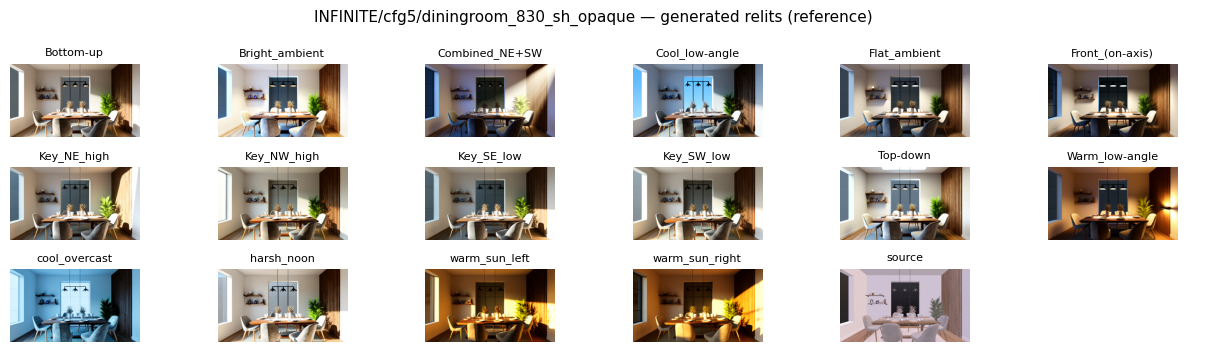

In [17]:
from PIL import Image
imgs = [(l["name"], np.asarray(Image.open(DS_DIR / f"light_{l['index']:03d}.png"))) for l in lights]
imgs.append(("source", np.asarray(Image.open(DS_DIR / "source.png"))))
ncol = 6; nrow = int(np.ceil(len(imgs) / ncol))
h, wd = imgs[0][1].shape[:2]
fig, ax = plt.subplots(nrow, ncol, figsize=(2.1 * ncol, 2.1 * nrow * h / wd))
for a, (nm, im) in zip(ax.ravel(), imgs):
    a.imshow(im); a.set_title(nm, fontsize=8); a.axis("off")
for a in ax.ravel()[len(imgs):]:
    a.axis("off")
fig.suptitle(f"{DOMAIN}/{GEN_CFG}/{SCENE} — generated relits (reference)", fontsize=11)
plt.tight_layout(); plt.show()

## 5. Estimated vs GT intrinsics

GT vs the decomposition estimate. `with_source` and `no_source` side by side.

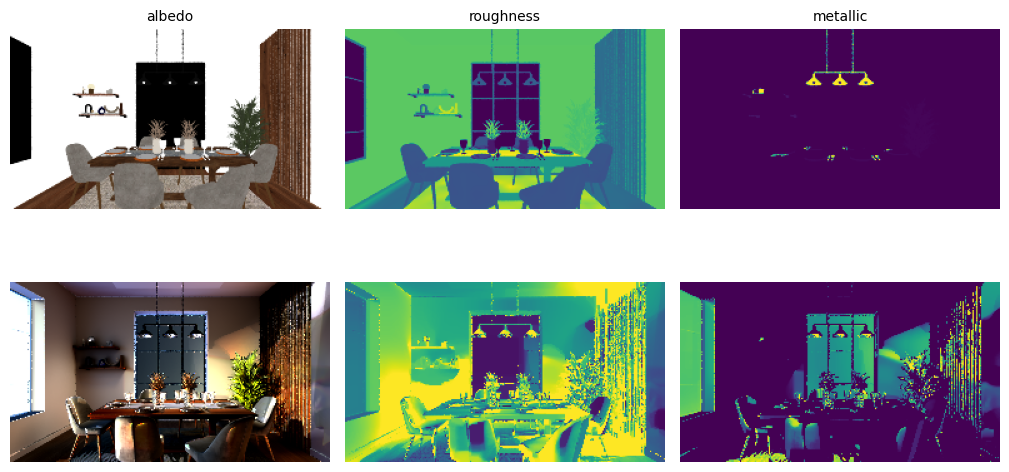

In [18]:
gt = load_gt_intrinsics(DS_DIR, DS)   # stride GT to the run's downsample
mask = gt["mask"]
maps = ["albedo", "roughness", "metallic"]
runs = [("GT", None)] + [(s, load_est_intrinsics(run_dir(s))) for s in SOURCES
                         if run_dir(s).exists()]
fig, ax = plt.subplots(len(runs), len(maps), figsize=(3.4 * len(maps), 3.0 * len(runs)))
ax = np.atleast_2d(ax)
for i, (name, est) in enumerate(runs):
    for j, k in enumerate(maps):
        m = gt[k] if est is None else est[k]
        m = m if m.ndim == 3 else m[..., None].repeat(3, -1)
        disp = np.clip(m, 0, 1).copy(); disp[~mask] = 1.0
        if k == "albedo":
            ax[i, j].imshow(disp)
        else:
            ax[i, j].imshow(disp[..., 0], cmap="viridis", vmin=0, vmax=1)
        ax[i, j].axis("off")
        if i == 0: ax[i, j].set_title(k, fontsize=10)
    ax[i, 0].set_ylabel(name, fontsize=10, rotation=0, ha="right", va="center")
plt.tight_layout(); plt.show()

## 6. Relight comparison — EST vs GT intrinsics under a synthetic light

Both intrinsic sets rendered through identical GT geometry, so this isolates intrinsics quality.
Shown for a few azimuths.

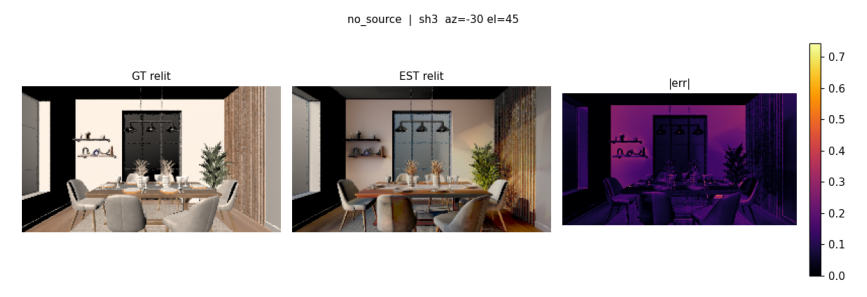

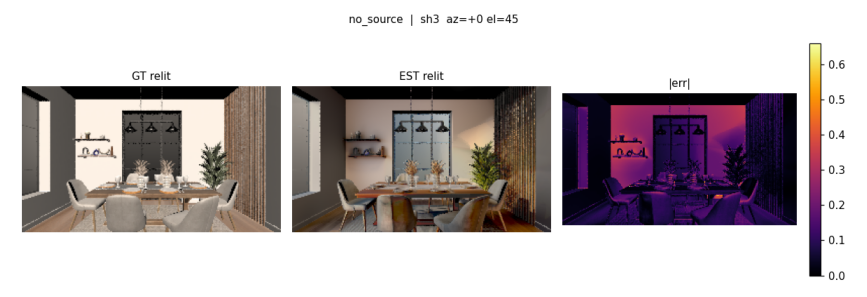

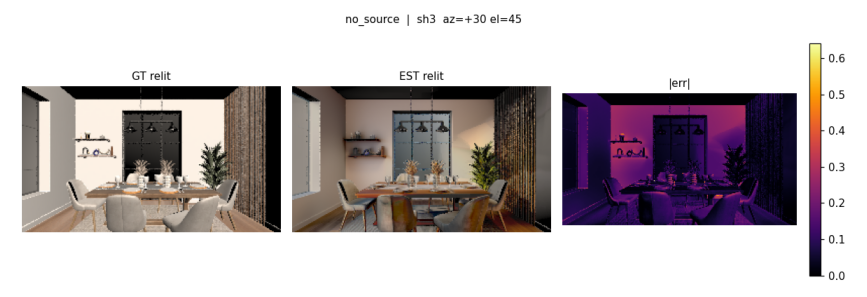

no_source    reference relight RMSE (est vs GT intrinsics): 0.1250


In [19]:
for az in (-30.0, 0.0, 30.0):
    outp = render_comparison(RUN_DIR, DS_DIR, mode="sh3", az=az, el=45.0, ds=DS, device=DEVICE)
    plt.figure(figsize=(11, 3.6)); plt.imshow(np.asarray(Image.open(outp))); plt.axis("off"); plt.show()

# scalar: mean EST-vs-GT relight RMSE over the fixed reference light set, per source variant
for s in SOURCES:
    if run_dir(s).exists():
        mean_rmse, _ = reference_relight_rmse(run_dir(s), DS_DIR, ds=DS, device=DEVICE)
        print(f"{s:12s} reference relight RMSE (est vs GT intrinsics): {mean_rmse:.4f}")

## 7. Relight video — GT vs EST intrinsics azimuth sweep

`GT | EST | |err|` as the light sweeps in azimuth. This is the *synthetic* relight comparison
(the named generated lightings have no GT SH to reproduce).

In [20]:
from IPython.display import Video, Image as IPyImage
vid = render_relight_video(RUN_DIR, DS_DIR, mode="env_sharp", az_from=-45, az_to=45,
                           n_frames=41, ds=DS, device=DEVICE, fps=18)
print("wrote", vid)
display(Video(vid, embed=True, width=780) if vid.endswith(".mp4") else IPyImage(vid))

wrote /home/felix/Projects/image-intrinsics/results/generated_study/metallic_l1_1e-2_tv1e-3_light_mono/INFINITE/cfg5/diningroom_830_sh_opaque/no_source/relight_env_sharp.mp4
